In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import pyvista as pv
from desmin_reconstruction.plotting.renderings import (
    render_boundingsquare,
    render_pointcloud,
)
from desmin_reconstruction.preprocessing.bbox import BoundingSquare, filter_bounded


plt.rc("font", size=12)
plt.rc("grid", linestyle="--", color="lightgray")
plt.rc("axes.spines", right=False, top=False)
pv.set_jupyter_backend("static")

datadir = Path("../data/")

In [2]:
df = pl.read_csv(datadir / "results/desmin_alphaactinin_2.5um_filtered.csv")
out = df.partition_by("probe")

In [3]:
points = [o.select(["x", "y", "z"]).to_numpy() for o in out]

2026-06-27 20:00:28.212 ( 119.171s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0xe3a7da0): Unable to eglMakeCurrent: 12291
2026-06-27 20:00:28.268 ( 119.227s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0xe36ddc0): Unable to eglMakeCurrent: 12291
2026-06-27 20:00:28.353 ( 119.311s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0xe3a7da0): Unable to eglMakeCurrent: 12291


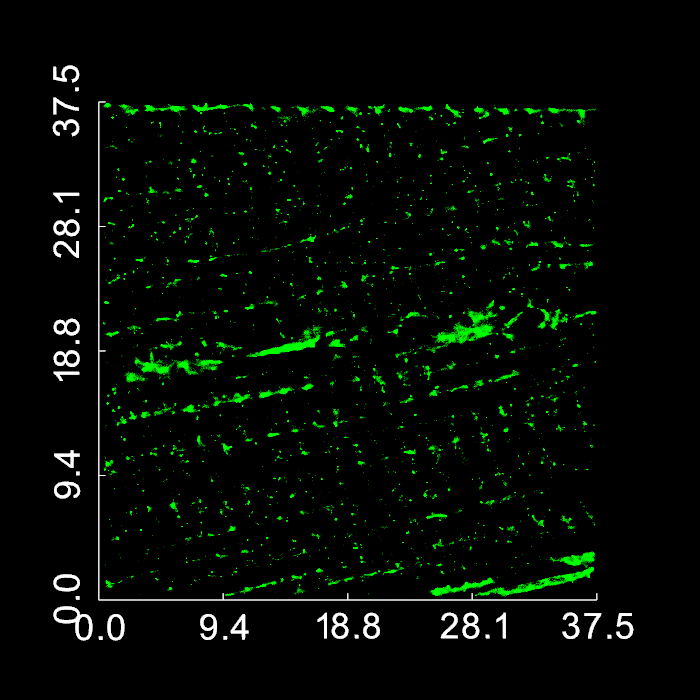

In [ ]:
p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points[0],
    color="#FF0000",
    point_size=0.4,
    opacity=0.4,
)
p = render_pointcloud(
    p,
    points[1],
    color="#00FF00",
    point_size=0.4,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=26,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
bbox = BoundingSquare(0.5, 1.1, 12)
#p = render_boundingsquare(p, bbox, z_height=4.0)
p.show()
p.save_graphic("../figures/fig_1/1b/overlay.svg")

2026-06-27 20:10:22.938 ( 713.896s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c535e0): Unable to eglMakeCurrent: 12291
2026-06-27 20:10:22.959 ( 713.918s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c4bf20): Unable to eglMakeCurrent: 12291
2026-06-27 20:10:23.004 ( 713.963s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c535e0): Unable to eglMakeCurrent: 12291


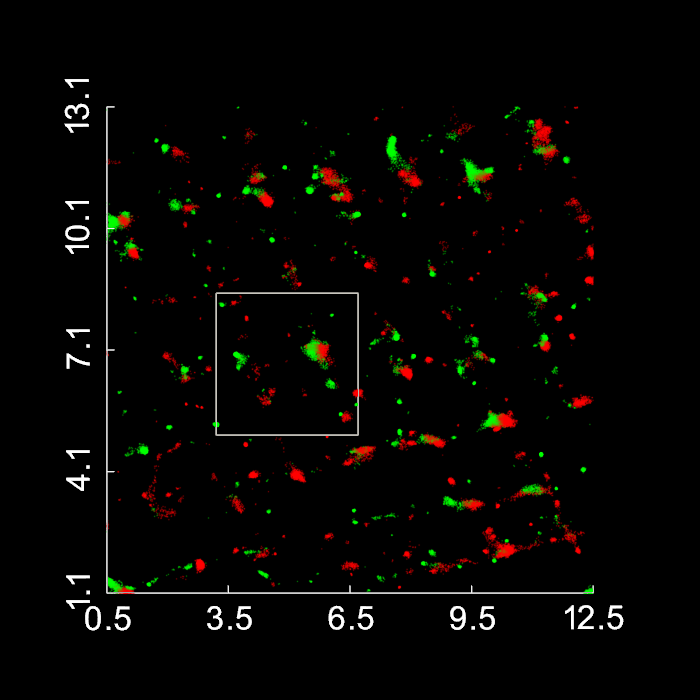

In [11]:
points_roi = [filter_bounded(pts, bbox) for pts in points]

p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points_roi[0],
    color="#FF0000",
    point_size=1.0,
    opacity=0.4,
)
p = render_pointcloud(
    p,
    points_roi[1],
    color="#00FF00",
    point_size=1.0,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    # bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=26,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
bbox = BoundingSquare(3.2, 5, 3.5)
p = render_boundingsquare(p, bbox, z_height=4.0)
p.show()
p.save_graphic("../figures/fig_1/1b/roi.svg")

2026-06-27 20:10:37.689 ( 728.648s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c55560): Unable to eglMakeCurrent: 12291
2026-06-27 20:10:37.710 ( 728.669s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c4bf20): Unable to eglMakeCurrent: 12291
2026-06-27 20:10:37.747 ( 728.705s) [    148898DD7740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x28c55560): Unable to eglMakeCurrent: 12291


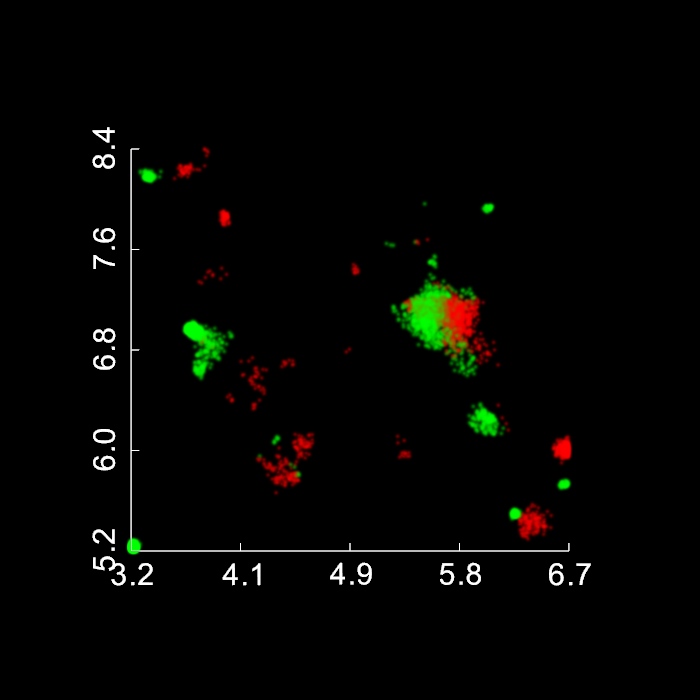

In [12]:
points_roi2 = [filter_bounded(pts, bbox) for pts in points_roi]
p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points_roi2[0],
    color="#FF0000",
    point_size=3.0,
    opacity=0.4,
)
p = render_pointcloud(
    p,
    points_roi2[1],
    color="#00FF00",
    point_size=3.0,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    # bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=26,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
p.show()
p.save_graphic("../figures/fig_1/1b/roi2.svg")

## Visualize the desmin / actin 2.5um stack

In [2]:
df = pl.read_csv(datadir / "results/desmin_actin_2.5um_filtered.csv")
out = df.partition_by("probe")
points = [o.select(["x", "y", "z"]).to_numpy() for o in out]

In [49]:
for p in points:
    print(len(p))

466741
1294498


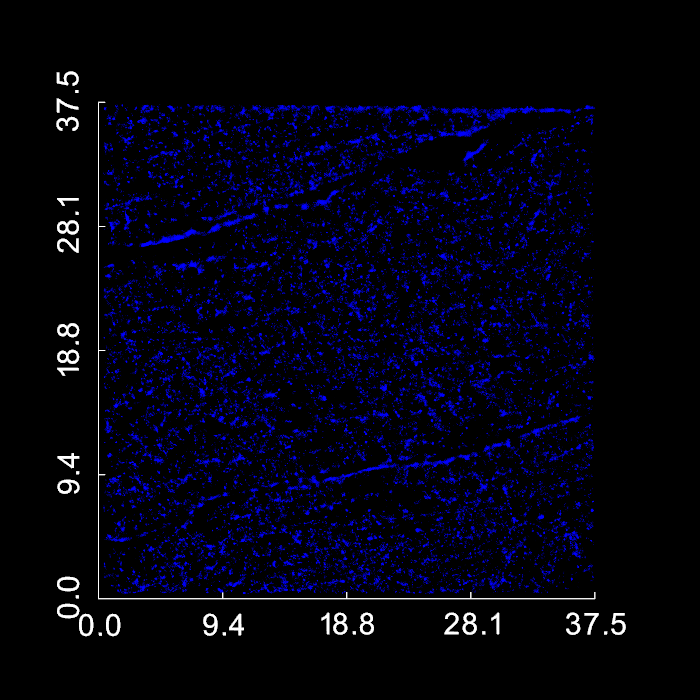

In [ ]:
p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points[1],
    color="#FF0000",
    point_size=0.4,
    opacity=0.2,
)
p = render_pointcloud(
    p,
    points[0],
    color="#0000FF",
    point_size=0.4,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
bbox = BoundingSquare(14, 14, 12)
p = render_boundingsquare(p, bbox, z_height=4.0)
p.show()
p.save_graphic("../figures/fig_3/3e/overlay.svg")

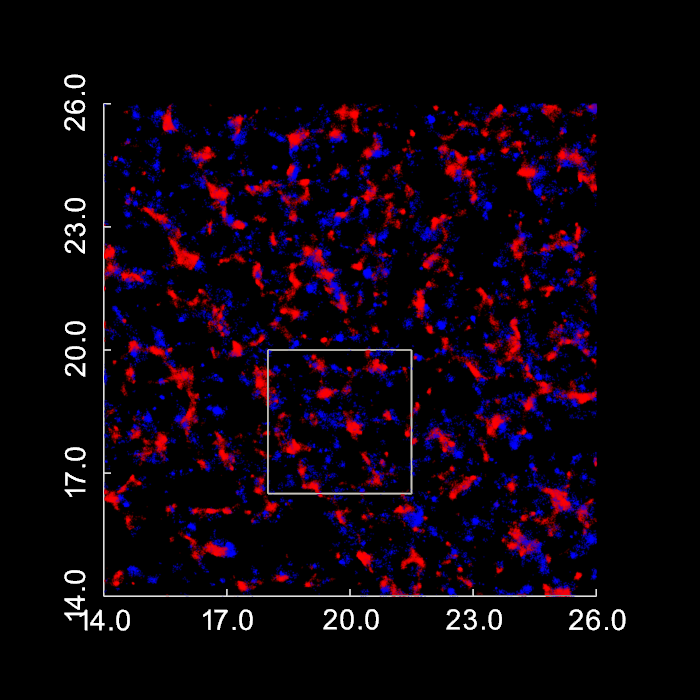

In [63]:
points_roi = [filter_bounded(pts, bbox) for pts in points]

p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points_roi[1],
    color="#FF0000",
    point_size=1.0,
    opacity=0.2,
)
p = render_pointcloud(
    p,
    points_roi[0],
    color="#0000FF",
    point_size=1.0,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    # bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
bbox2 = BoundingSquare(18, 16.5, 3.5)
p = render_boundingsquare(p, bbox2, z_height=3.0)
p.show()
p.save_graphic("../figures/fig_3/3e/roi.svg")

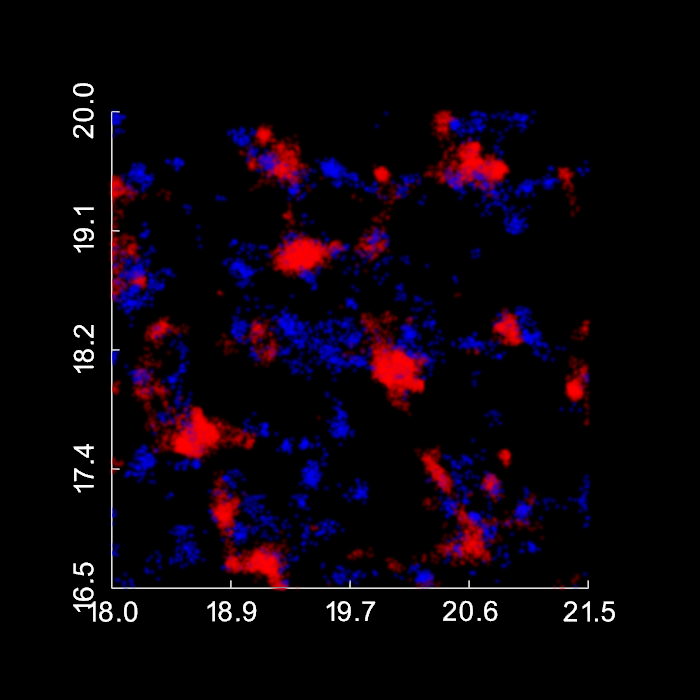

In [64]:
points_roi2 = [filter_bounded(pts, bbox2) for pts in points_roi]
p = pv.Plotter(notebook=True, window_size=(700, 700))
p = render_pointcloud(
    p,
    points_roi2[1],
    color="#FF0000",
    point_size=3.0,
    opacity=0.2,
)
p = render_pointcloud(
    p,
    points_roi2[0],
    color="#0000FF",
    point_size=3.0,
    opacity=0.4,
)
p.show_bounds(
    color="white",
    # bounds=[0, 37.5, 0, 37.5, 0, 0],
    grid=None,
    bold=False,
    font_size=22,
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    show_zaxis=False,
    xtitle="",
    ytitle="",
)
p.show()
p.save_graphic("../figures/fig_3/3e/roi2.svg")